In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gget
from tqdm import tqdm
from scipy.stats import ttest_ind
import matplotlib.colors as mcolors
import os
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

import rapids_singlecell as rsc
import anndata as an
import scanpy as sc
import scvi
from cuml import UMAP

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# GO Functions

In [2]:
def get_genes_from_go_path(go_pathname, file_path="../../../resources/GO_Biological_Process_2023.txt"):
    """
    Reads a tab-delimited file where each line starts with a GO pathway name,
    then returns a list of genes in the row where the pathway name matches `go_pathname`.
    """
    with open(file_path, 'r') as f:
        for line in f:
            # Remove newline and split by tab
            parts = line.strip().split('\t')
            # The first column is the pathway name
            if parts[0].strip() == go_pathname.strip():
                # Genes are all non-empty fields after the first two columns
                # (since there are 2 tabs after the pathway name in your file)
                genes = [x for x in parts[2:] if x]
                return genes
    return []

def search_go_pathways(search_str, file_path="../../../resources/GO_Biological_Process_2023.txt"):
    """
    Returns a list of pathway names containing `search_str` (case-insensitive).
    """
    pathways = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if search_str.lower() in parts[0].lower():
                pathways.append(parts[0])
    return pathways


def pathways_with_genes(gene_list, file_path="../../../resources/GO_Biological_Process_2023.txt"):
    """
    Returns all pathways where every gene in `gene_list` is present in that pathway's gene set.
    """
    results = []
    genes_set = set(gene_list)
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            pathway = parts[0]
            # Genes start after two tab columns
            pathway_genes = set([x for x in parts[2:] if x])
            if genes_set.issubset(pathway_genes):
                results.append(pathway)
    return results


results = search_go_pathways("cell cycle")
print("First 5 pathways containing 'cell cycle':")
print(results[:5])

gene_list = get_genes_from_go_path(results[0])
print(f"\nGenes in pathway '{results[0]}':")
print(gene_list)

results_with_cd34 = pathways_with_genes(['CD34'])
print("\nFirst 5 pathways containing gene 'CD34':")
print(results_with_cd34[:5])

First 5 pathways containing 'cell cycle':
['DNA Damage Response, Signal Transduction By P53 Class Mediator Resulting In Cell Cycle Arrest (GO:0006977)', 'G1/S Transition Of Mitotic Cell Cycle (GO:0000082)', 'G2/M Transition Of Mitotic Cell Cycle (GO:0000086)', 'Cell Cycle G1/S Phase Transition (GO:0044843)', 'Cell Cycle G2/M Phase Transition (GO:0044839)']

Genes in pathway 'DNA Damage Response, Signal Transduction By P53 Class Mediator Resulting In Cell Cycle Arrest (GO:0006977)':
['CDKN1B', 'GML', 'CDKN1A', 'PLK3', 'CRADD', 'PLK2', 'TRIAP1', 'PML', 'MUC1', 'PRAP1', 'CHEK2', 'CASP2', 'RPL26', 'GTSE1', 'PIDD1', 'TP53', 'MDM2']

First 5 pathways containing gene 'CD34':
['Angiogenesis Involved In Wound Healing (GO:0060055)', 'Cell-Matrix Adhesion (GO:0007160)', 'Endothelial Cell Proliferation (GO:0001935)', 'Endothelium Development (GO:0003158)', 'Epithelium Development (GO:0060429)']


# Load gene sets

In [3]:
# load tfs so I got 'em
fpath = "../../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:5]

['ZNF354C', 'KLF12', 'ZNF143', 'ZIC2', 'ZNF274']

In [4]:
fpath = "../../../resources/clean_marker_genes.csv"
mdf = pd.read_csv(fpath)
mdf['val'] = 1
print(mdf.head().to_string(index=False))

gene_name         cell_type  is_tf  source    category  val
   TSPAN8 endothelial_cells  False panglao endothelial    1
     KLK1 endothelial_cells  False panglao endothelial    1
   RNASE1 endothelial_cells  False panglao endothelial    1
      LUM endothelial_cells  False panglao endothelial    1
      LOX endothelial_cells  False panglao endothelial    1


In [5]:
mdf_pivot = pd.pivot_table(
    mdf, 
    index=['gene_name',],
    columns=['source', 'category'],
    values='val',
    fill_value=0
)

mdf_pivot.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in mdf_pivot.columns]

mdf_pivot.head()

,panglao_endothelial,panglao_fibroblast,panglao_hematopoietic,tabula_endothelial,tabula_fibroblast,tabula_hematopoietic
gene_name,,,,,,
A2M,1.0,0.0,0.0,1.0,1.0,0.0
ABCA8,1.0,0.0,0.0,0.0,0.0,0.0
ABCB1,0.0,0.0,1.0,0.0,0.0,0.0
ABCG2,1.0,0.0,1.0,0.0,0.0,0.0
ABI3,0.0,1.0,0.0,0.0,0.0,0.0


# Load data

In [6]:
### %%time
dpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scMINER/hsc_clusters/SJARACNe/"
alpha = 0.01

clusters = ["C1", "C2", "C3", "C4", "C5"]

df_list = []

for c in clusters:
    fpath = f"{dpath}{c}/output/consensus_network_ncol_.txt"
    df = pd.read_csv(fpath, sep='\t')
    df = df.drop(columns=['source.symbol', 'target.symbol'])
    df['cluster'] = c
    df['sig'] = (df['p-value'] <= alpha)
    df_list.append(df)

df = pd.concat(df_list)
df['pair'] = df['source'] + " → " + df['target']
print(f"{df.shape=}")
print(df.head().to_string())

df.shape=(1044554, 10)
  source   target      MI  pearson  spearman   slope  p-value cluster    sig            pair
0   AATF    ACSL4  0.1007   0.1194    0.1096  0.2190   0.0005      C1   True    AATF → ACSL4
1   AATF  ADAMTS1  0.0917   0.1336    0.1242  0.9153   0.0001      C1   True  AATF → ADAMTS1
2   AATF    ADAT1  0.1066   0.1291    0.1187  0.1188   0.0002      C1   True    AATF → ADAT1
3   AATF  ADIPOR1  0.1037   0.1732    0.1417  0.2654   0.0000      C1   True  AATF → ADIPOR1
4   AATF   ANP32E  0.0888   0.0598    0.0978  0.0922   0.0842      C1  False   AATF → ANP32E


# Simple filtering

In [7]:
print(f"Original edges: {len(df)}")

# Filter source
df = df[~df['source'].str.startswith("MT")]
df = df[~df['source'].str.startswith("RP")]
print(f"After source filter: {len(df)} edges")

# Filter target
df = df[~df['target'].str.startswith("MT")]
df = df[~df['target'].str.startswith("RP")]
print(f"After target filter: {len(df)} edges")

# Reset index
df = df.reset_index(drop=True)
print("Index reset.\n")

# Show preview
print(df.head())


Original edges: 1044554
After source filter: 1040085 edges
After target filter: 997109 edges
Index reset.

  source   target      MI  pearson  spearman   slope  p-value cluster    sig  \
0   AATF    ACSL4  0.1007   0.1194    0.1096  0.2190   0.0005      C1   True   
1   AATF  ADAMTS1  0.0917   0.1336    0.1242  0.9153   0.0001      C1   True   
2   AATF    ADAT1  0.1066   0.1291    0.1187  0.1188   0.0002      C1   True   
3   AATF  ADIPOR1  0.1037   0.1732    0.1417  0.2654   0.0000      C1   True   
4   AATF   ANP32E  0.0888   0.0598    0.0978  0.0922   0.0842      C1  False   

             pair  
0    AATF → ACSL4  
1  AATF → ADAMTS1  
2    AATF → ADAT1  
3  AATF → ADIPOR1  
4   AATF → ANP32E  


# Re-structure

In [8]:
%%time 
pdf = df.copy()

pdf = pd.pivot_table(
    pdf,
    index=['source', 'target'],
    columns=['cluster'],
    values=['MI', 'pearson', 'spearman', 'sig'],
    fill_value=0
)

# Flatten multi-index columns by joining with underscore
pdf.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in pdf.columns]
pdf = pdf.reset_index()
print(f"{pdf.shape=}")
print(pdf.columns)

print(pdf[['source', 'target', 'MI_C1', 'MI_C2', 'MI_C3', 'MI_C4', 'MI_C5',]].head().to_string())

pdf.shape=(873371, 22)
Index(['source', 'target', 'MI_C1', 'MI_C2', 'MI_C3', 'MI_C4', 'MI_C5',
       'pearson_C1', 'pearson_C2', 'pearson_C3', 'pearson_C4', 'pearson_C5',
       'sig_C1', 'sig_C2', 'sig_C3', 'sig_C4', 'sig_C5', 'spearman_C1',
       'spearman_C2', 'spearman_C3', 'spearman_C4', 'spearman_C5'],
      dtype='object')
  source target  MI_C1   MI_C2   MI_C3   MI_C4  MI_C5
0   AATF  ABCF3    0.0  0.0841  0.0000  0.0000    0.0
1   AATF   ABI1    0.0  0.0000  0.1088  0.0000    0.0
2   AATF  ACBD4    0.0  0.0000  0.0689  0.0000    0.0
3   AATF  ACIN1    0.0  0.0000  0.0000  0.0839    0.0
4   AATF   ACO1    0.0  0.0000  0.0000  0.0863    0.0
CPU times: user 765 ms, sys: 303 ms, total: 1.07 s
Wall time: 1.07 s


In [9]:
# add foldchanges

mi_cols = ['MI_C1', 'MI_C2', 'MI_C3', 'MI_C4', 'MI_C5']
fc_columns = []
# Compute log2 fold change of each value vs. mean of other columns in the row
for col in mi_cols:
    others = [c for c in mi_cols if c != col]
    new_column = f'log2FC_{col.replace("MI_", "")}'
    pdf[new_column] = np.log2((pdf[col] + 1) / (pdf[others].mean(axis=1) + 1))
    fc_columns.append(new_column)

print(pdf[['source', 'target'] + fc_columns].head().to_string())

  source target  log2FC_C1  log2FC_C2  log2FC_C3  log2FC_C4  log2FC_C5
0   AATF  ABCF3  -0.030018   0.116498  -0.030018  -0.030018  -0.030018
1   AATF   ABI1  -0.038717  -0.038717   0.148999  -0.038717  -0.038717
2   AATF  ACBD4  -0.024639  -0.024639   0.096127  -0.024639  -0.024639
3   AATF  ACIN1  -0.029948  -0.029948  -0.029948   0.116232  -0.029948
4   AATF   ACO1  -0.030795  -0.030795  -0.030795   0.119423  -0.030795


In [10]:
tdf = pdf.copy()
tdf = tdf[tdf['source'].isin(tf_list)]
tdf = tdf[tdf['target'].isin(tf_list)]
print(f"{tdf.shape=}")
tdf.head()

tdf.shape=(48398, 27)


,source,target,MI_C1,MI_C2,MI_C3,MI_C4,MI_C5,pearson_C1,pearson_C2,pearson_C3,...,spearman_C1,spearman_C2,spearman_C3,spearman_C4,spearman_C5,log2FC_C1,log2FC_C2,log2FC_C3,log2FC_C4,log2FC_C5
664,ADNP,ABL1,0.1479,0.0000,0.0,0.1114,0.0000,0.3373,0.0000,0.0,...,0.2830,0.0000,0.0,0.1385,0.0000,0.159367,-0.090616,-0.090616,0.099997,-0.090616
681,ADNP,AFF4,0.1576,0.1031,0.0,0.0000,0.0000,0.2735,0.1741,0.0,...,0.2456,0.1852,0.0,0.0000,0.0000,0.174423,0.085813,-0.091090,-0.091090,-0.091090
683,ADNP,AGMAT,0.0000,0.0000,0.0,0.0000,0.0718,0.0000,0.0000,0.0,...,0.0000,0.0000,0.0,0.0000,0.0375,-0.025667,-0.025667,-0.025667,-0.025667,0.100036
684,ADNP,AHCTF1,0.0000,0.1055,0.0,0.0000,0.0000,0.0000,0.1923,0.0,...,0.0000,0.1513,0.0,0.0000,0.0000,-0.037558,0.144699,-0.037558,-0.037558,-0.037558
685,ADNP,AHDC1,0.0000,0.0000,0.0,0.0979,0.0000,0.0000,0.0000,0.0,...,0.0000,0.0000,0.0,0.1446,0.0000,-0.034885,-0.034885,-0.034885,0.134747,-0.034885


# Build graph

In [11]:
%%time
G = nx.from_pandas_edgelist(
    # tdf, # could be pdf for all interactions
    pdf, # could be tdf for tf-tf interactions
    edge_attr=True,
    create_using=nx.DiGraph(),
)

nx.set_node_attributes(G, {n: True for n in tf_list if n in G}, 'is_tf')

attrs = nx.get_node_attributes(G, 'is_tf')
n_true = sum(attrs.values())
n_total = G.number_of_nodes()

print(f"{n_true} / {n_total} nodes are TFs")

print(G)

1484 / 21157 nodes are TFs
DiGraph with 21157 nodes and 873371 edges
CPU times: user 3.94 s, sys: 483 ms, total: 4.43 s
Wall time: 4.44 s


# Get Expression Data

In [12]:
%%time

# File path
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
print(f"Loading AnnData from: {fpath}")
adata = sc.read_h5ad(fpath)

# Use log-normalized layer
adata.X = adata.layers['log_norm'].copy()
print("Set `adata.X` to 'log_norm' layer.")

# Filter genes to match nodes in the graph
nodes = list(G.nodes())
print(f"Filtering genes to {len(nodes)} nodes in the graph...")
adata = adata[:, nodes].copy()

# Extract expression matrix and cluster labels
expr_df = adata.to_df()
clusters = adata.obs['cluster_str']
print(f"Expression matrix shape: {expr_df.shape}")
print(f"Number of unique clusters: {clusters.nunique()}")

# Compute mean and non-zero percentage per gene per cluster
stats = {}
for clust in clusters.unique():
    print(f"Processing cluster: {clust}")
    mask = clusters == clust
    X_cluster = expr_df[mask]
    stats[f'mean_{clust}'] = X_cluster.mean()
    stats[f'nonzero_pct_{clust}'] = (X_cluster > 0).sum() / X_cluster.shape[0] * 100

# Combine stats into a single DataFrame
X = pd.DataFrame(stats)
X.index.name = 'gene'

# Convert the DataFrame to a dict-of-dicts: {node: {attr_name: value, ...}, ...}
attr_dict = X.to_dict(orient='index')
nx.set_node_attributes(G, attr_dict)

print(f"Final stats shape: {X.shape}")
print("Columns in output:")
print(X.columns.tolist())
print(X.head().to_string())

Loading AnnData from: /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad
Set `adata.X` to 'log_norm' layer.
Filtering genes to 21157 nodes in the graph...
Expression matrix shape: (15867, 21157)
Number of unique clusters: 5
Processing cluster: C3
Processing cluster: C4
Processing cluster: C5
Processing cluster: C2
Processing cluster: C1
Final stats shape: (21157, 10)
Columns in output:
['mean_C3', 'nonzero_pct_C3', 'mean_C4', 'nonzero_pct_C4', 'mean_C5', 'nonzero_pct_C5', 'mean_C2', 'nonzero_pct_C2', 'mean_C1', 'nonzero_pct_C1']
        mean_C3  nonzero_pct_C3   mean_C4  nonzero_pct_C4   mean_C5  nonzero_pct_C5   mean_C2  nonzero_pct_C2   mean_C1  nonzero_pct_C1
gene                                                                                                                                   
AATF   0.135796       20.504253  0.218729       37.992750  0.160086       22.429907  0.117485       17.143948  0.124763       22.302158
ABCF3  0.101

# Group-specific centralities

In [13]:
%%time

centrality_results = []

clusters = df['cluster'].unique()
print(f"Calculating centralities for {len(clusters)} clusters: {clusters}")

for i, cluster in enumerate(clusters, 1):
    print(f"[{i}/{len(clusters)}] Processing cluster: {cluster}")
    weight = f"MI_{cluster}"

    # Eigenvector centrality
    print(f"    Calculating eigenvector centrality (weighted by {weight})...")
    ec = nx.eigenvector_centrality(G, max_iter=1000, weight=weight)
    ec_df = pd.DataFrame.from_dict(ec, orient='index', columns=['eigenvector_centrality'])
    ec_df['eigenvector_centrality_norm'] = (
        (ec_df['eigenvector_centrality'] - ec_df['eigenvector_centrality'].min()) /
        (ec_df['eigenvector_centrality'].max() - ec_df['eigenvector_centrality'].min())
    )
    
    # Add gene and cluster info
    ec_df['gene_name'] = ec_df.index
    ec_df['cluster'] = cluster
    ec_df['centrality_rank'] = ec_df['eigenvector_centrality'].rank(ascending=False, method='min')
    centrality_results.append(ec_df.reset_index(drop=True))

print("Combining cluster-specific centrality data...")
final_df = pd.concat(centrality_results, ignore_index=True)

# Reorder columns
final_df = final_df[['gene_name', 'cluster', 
                     'eigenvector_centrality', 'eigenvector_centrality_norm','centrality_rank']]

print("Centrality calculation complete. Example output:")
print(final_df.head().to_string())

Calculating centralities for 5 clusters: ['C1' 'C2' 'C3' 'C4' 'C5']
[1/5] Processing cluster: C1
    Calculating eigenvector centrality (weighted by MI_C1)...
[2/5] Processing cluster: C2
    Calculating eigenvector centrality (weighted by MI_C2)...
[3/5] Processing cluster: C3
    Calculating eigenvector centrality (weighted by MI_C3)...
[4/5] Processing cluster: C4
    Calculating eigenvector centrality (weighted by MI_C4)...
[5/5] Processing cluster: C5
    Calculating eigenvector centrality (weighted by MI_C5)...
Combining cluster-specific centrality data...
Centrality calculation complete. Example output:
  gene_name cluster  eigenvector_centrality  eigenvector_centrality_norm  centrality_rank
0      AATF      C1                0.001522                     0.014155           5833.0
1     ABCF3      C1                0.000252                     0.002342           9191.0
2      ABI1      C1                0.021481                     0.199814            479.0
3     ACBD4      C1   

In [14]:
pdf = final_df.copy()
pdf = pd.pivot_table(
    pdf, 
    index='gene_name',
    columns='cluster',
    values='eigenvector_centrality_norm',
    fill_value=0.0,
)

pdf.mean(axis=0)

# Compute means for each gene
pdf['mean_reprogram'] = pdf[['C2', 'C3']].mean(axis=1)
pdf['mean_control'] = pdf[['C4', 'C5']].mean(axis=1)

min_nonzero = pdf[['mean_reprogram', 'mean_control']].replace(0, np.nan).min().min()
min_nonzero

# Add nudge to numerator and denominator
eps = 1e-6
pdf['foldchanges'] = np.log2((pdf['mean_reprogram'] + eps) / (pdf['mean_control'] + eps))
pdf = pdf.sort_values('foldchanges', ascending=False)

pdf = pdf.reset_index()
print(pdf[['gene_name', 'foldchanges']].head(15).to_string(index=False))

 gene_name  foldchanges
    SCARA5    15.886336
     RFLNA    15.700960
      AQP3    15.523258
      BTG2    15.174803
       PPL    15.162003
   PLEKHO2    15.144970
    DEPTOR    15.038616
      SDC3    15.036184
     EDEM2    14.664619
    COMMD5    14.623405
      MSX1    14.442705
      LEPR    14.278633
    ARRDC1    14.257973
ATP6AP1-DT    14.210965
ZNF528-AS1    14.047579


In [15]:
print(pdf[pdf['gene_name'].isin(tf_list)][['gene_name', 'foldchanges']].tail(10).to_string(index=False))

gene_name  foldchanges
    SOX11    -7.557500
     KLF2    -7.576915
    MYEF2    -7.664717
   ZNF521    -8.077961
    ZFP92    -8.518067
      EHF    -8.626906
     IRF7    -8.833723
   HOXD13    -9.322481
     EBF3    -9.741659
     SIM1   -10.129980


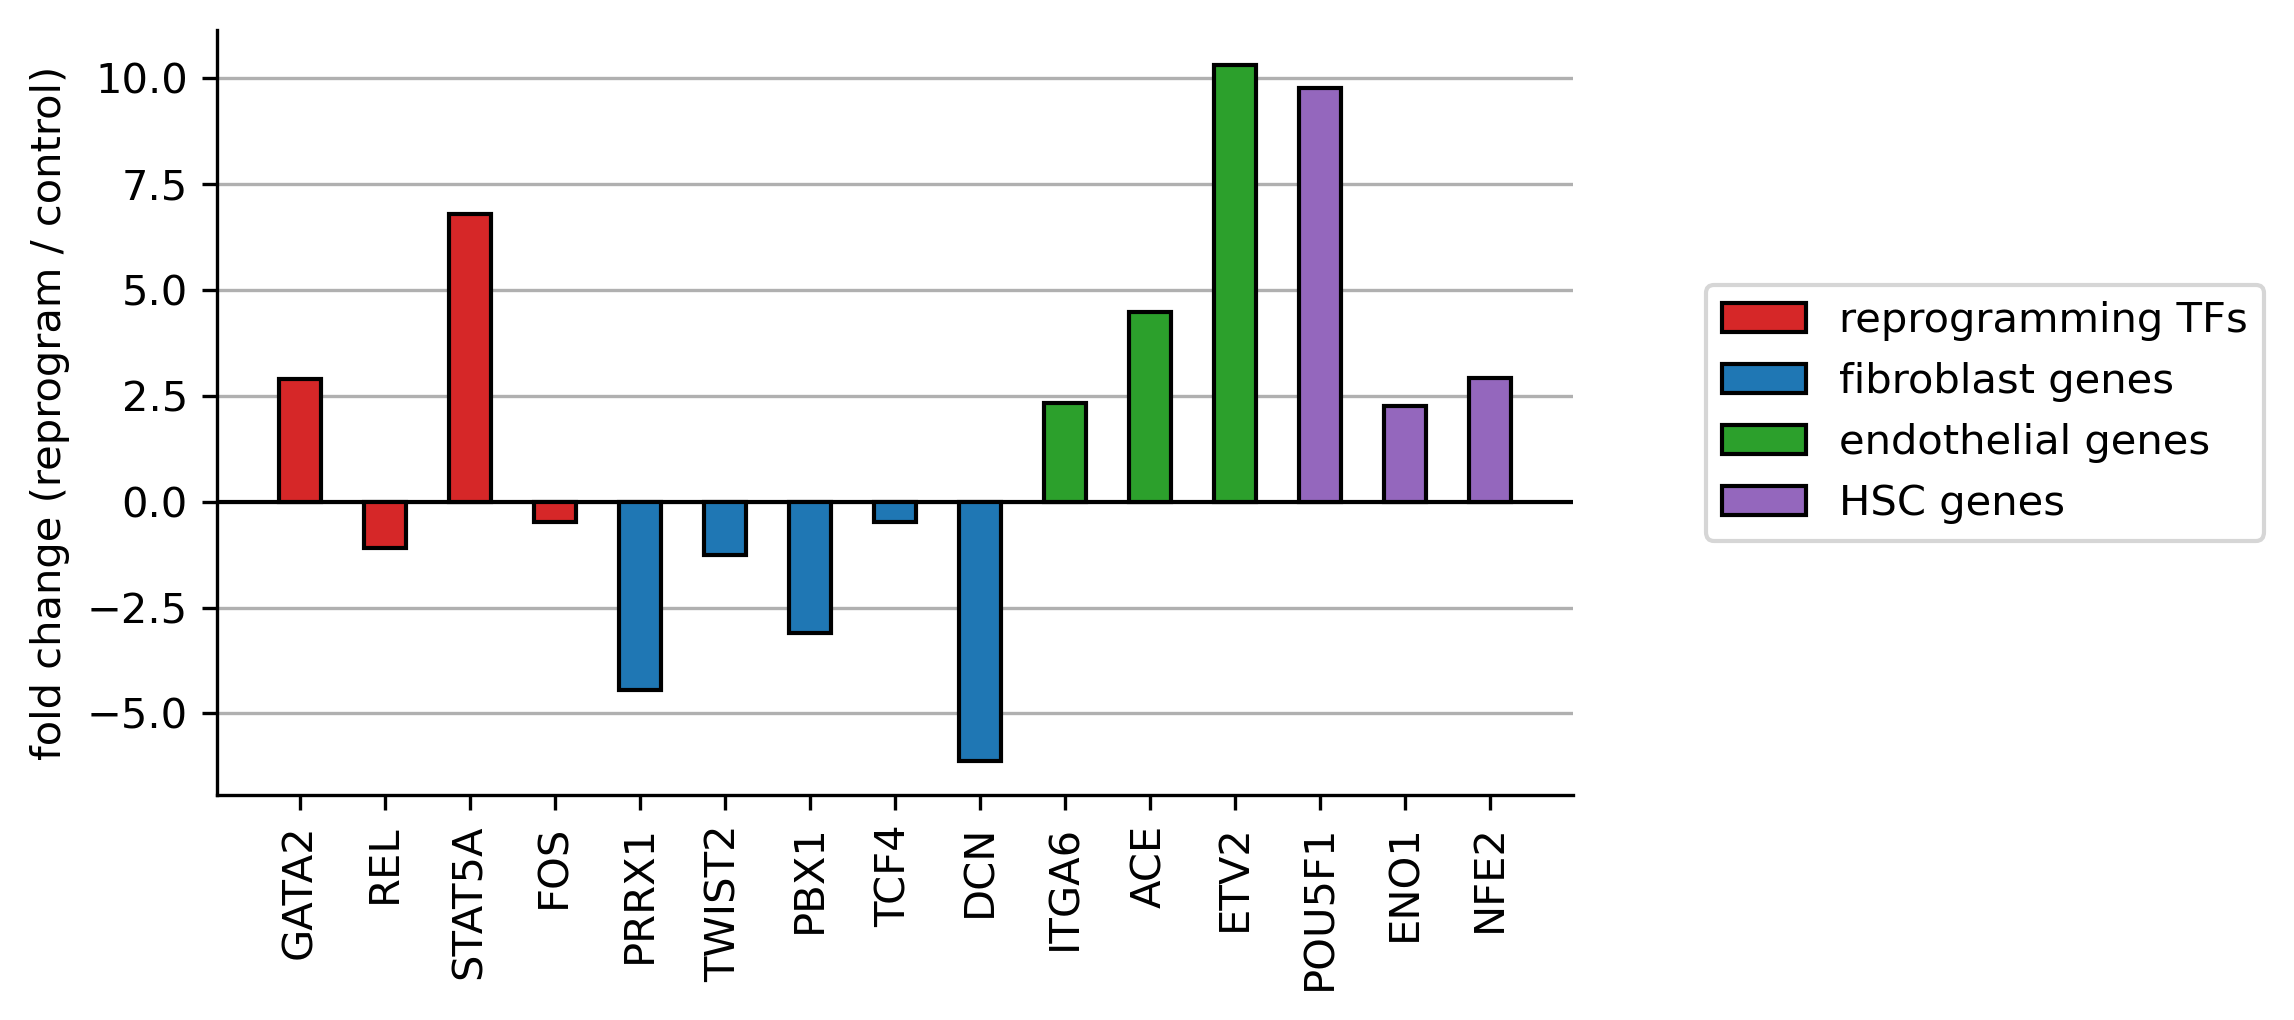

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Define gene categories and colors
gene_categories = {
    "reprogramming TFs": ['GATA2', 'REL', 'STAT5A', 'FOS'],
    "fibroblast genes": ['PRRX1', 'TWIST2', 'PBX1', 'TCF4', 'DCN'],
    "endothelial genes": ['ITGA6', 'ACE', 'ETV2'],
    "HSC genes": ['POU5F1', 'ENO1', 'NFE2'],
}
category_colors = {
    "reprogramming TFs": "#d62728",   # red
    "fibroblast genes": "#1f77b4",    # blue
    "endothelial genes": "#2ca02c",   # green
    "HSC genes": "#9467bd",           # purple
}
# Flatten and map
gene2cat = {g: cat for cat, genes in gene_categories.items() for g in genes}
gene2color = {g: category_colors[gene2cat[g]] for g in gene2cat}

# Query gene order
query = [
    'GATA2', 'REL', 'STAT5A', 'FOS',      # reprogramming factors
    'PRRX1', 'TWIST2', 'PBX1', 'TCF4', 'DCN', # Fibroblast genes
    'ITGA6', 'ACE', 'ETV2',               # endothelial genes
    'POU5F1', 'ENO1', 'NFE2',             # hsc genes
]

# Filter and annotate plot_df
plot_df = pdf[pdf['gene_name'].isin(query)].copy()
plot_df['category'] = plot_df['gene_name'].map(gene2cat)
plot_df['color'] = plot_df['gene_name'].map(gene2color)
plot_df['plot_order'] = plot_df['gene_name'].apply(lambda x: query.index(x))
plot_df = plot_df.sort_values('plot_order')

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 9, 3.5

fig, ax = plt.subplots()

bars = ax.bar(
    x=plot_df['gene_name'],
    height=plot_df['foldchanges'],
    color=plot_df['color'],
    edgecolor='k',
    width=0.5,
    zorder=3,
)

ax.axhline(y=0, c='k', lw=1)
ax.set_ylabel("fold change (reprogram / control)")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=90)
ax.yaxis.grid(True, zorder=0)
sns.despine()

# Legend
legend_handles = [
    Patch(facecolor=category_colors[cat], edgecolor='k', label=cat)
    for cat in gene_categories
]
ax.legend(
    handles=legend_handles, 
    title="", 
    bbox_to_anchor=(1.51, 0.5), 
    loc="center right", 
    borderaxespad=0.)

plt.tight_layout()
plt.show()


In [17]:
# tf_recipe = ['GATA2', 'REL', 'STAT5A', 'FOS']
# plot_df = final_df.copy()
# plot_df = plot_df[plot_df['gene_name'].isin(tf_recipe)]

# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['figure.figsize'] = (4, 3)

# ax = sns.barplot(
#     data=plot_df,
#     x='gene_name',
#     y='eigenvector_centrality_norm',
#     hue='cluster',
#     edgecolor='k',
#     zorder=4,
#     width=0.7,
# )

# # Labeling
# ax.set_xlabel("transcription factor", labelpad=10)
# ax.set_ylabel("centrality (normalized)", labelpad=10)
# ax.yaxis.grid(True, zorder=1)

# # Draw legend last with higher zorder
# legend = ax.legend(title="cluster", frameon=True)
# legend.set_zorder(3)
# sns.despine()

# # Optional: Tighter layout
# plt.tight_layout()
# plt.show()

In [18]:
# tf_recipe = ['PRRX1', 'TWIST2', 'PBX1', 'TCF4']
# plot_df = final_df.copy()
# plot_df = plot_df[plot_df['gene_name'].isin(tf_recipe)]

# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['figure.figsize'] = (4, 3)

# ax = sns.barplot(
#     data=plot_df,
#     x='gene_name',
#     y='eigenvector_centrality_norm',
#     hue='cluster',
#     edgecolor='k',
#     zorder=4,
#     width=0.7,
# )

# # Labeling
# ax.set_xlabel("transcription factor", labelpad=10)
# ax.set_ylabel("centrality (normalized)", labelpad=10)
# ax.yaxis.grid(True, zorder=1)

# # Draw legend last with higher zorder
# legend = ax.legend(title="cluster", frameon=True)
# legend.set_zorder(3)
# sns.despine()

# # Optional: Tighter layout
# plt.tight_layout()
# plt.show()

In [19]:
# plot_df = final_df.copy()

# plt.rcParams['figure.dpi'] = 200
# plt.rcParams['figure.figsize'] = 20, 4
# fig, axes = plt.subplots(1, 5)

# for i, (group_name, group) in enumerate(plot_df.groupby('cluster')):
#     group = group.sort_values('eigenvector_centrality', ascending=False)

#     sns.scatterplot(
#         data=group.head(20),
#         x='eigenvector_centrality',
#         y='gene_name',
#         hue='eigenvector_centrality',
#         size='eigenvector_centrality',
#         palette='Reds',
#         ec='k',
#         lw=0.5,
#         ax=axes[i],
#         zorder=5,
#     )
#     axes[i].set_ylabel("")
#     axes[i].set_xlabel("centrality")
#     axes[i].set_title(group_name)
#     axes[i].yaxis.grid(True, zorder=0)
#     sns.move_legend(
#         axes[i],
#         loc='lower right',
#         title=r'$r$', 
#     )

#     edf = gget.enrichr(group['gene_name'].head(20), database='ontology')
#     edf['genes'] = edf['overlapping_genes'].apply(
#         lambda x: ",".join(x[:5]) + ("..." if len(x) > 5 else "")
#     )
#     print(f"\n ======== {group_name} ======== ")
#     print(edf[['path_name', 'adj_p_val', 'genes']].head().to_string(index=False))
    
    
# plt.tight_layout()

In [20]:
plot_df = final_df.copy()
plot_df = pd.pivot_table(
    plot_df,
    index='gene_name',
    columns='cluster',
    values='eigenvector_centrality',
)

# ranks to mitigate scaling issues
plot_df = plot_df.rank(
    axis=0, 
    ascending=True,
    method='min',
    pct=True,
)

n = 10  # Number of top genes per cluster

for col in plot_df.columns:
    print(f"\nCluster: {col}")

    # Most central genes overall
    top_genes_col = plot_df[col].nsmallest(n).index.to_list()
    print("\tMost central genes:", ", ".join(top_genes_col))

    # Most central genes by cell type
    for cell_type, group in mdf.groupby('category'):
        mask = plot_df.index.isin(group['gene_name'])
        top_by_type = plot_df[mask][col].nsmallest(n).index.to_list()
        print(f"\tMost central {cell_type} genes:", ", ".join(top_by_type))


Cluster: C1
	Most central genes: AANAT, ABCA13, ABCB1, ABRA, ACSM3, ACTA1, ACVR2B-AS1, ADAMTS9, ADGRE2, ADH1A
	Most central endothelial genes: ADAMTS9, ADH1A, CYTL1, DLL4, ECSCR, FGD5, GFAP, IL1RL1, LYVE1, MRC1
	Most central fibroblast genes: FRZB, HGF, IL1RL1, SERPINB10, IL34, NFATC1, TNFAIP6, PRB3, HTRA3, APOE
	Most central hematopoietic genes: ABCB1, APOA1, CR1L, FGD5, HGF, KLRF1, LMO2, LYL1, LYVE1, MRC1

Cluster: C2
	Most central genes: AANAT, ABCA13, ABCB1, ABCC9, ACOT12, ACVR2B-AS1, ADAM23, ADAMTS9, ADAMTS9-AS2, ADCY5
	Most central endothelial genes: ADAMTS9, CLEC14A, CLEC1A, CPE, CSF3, CYTL1, CYYR1, DLL4, ECSCR, FABP4
	Most central fibroblast genes: ANGPTL7, CLEC14A, CXCL14, FABP4, FMOD, FNDC1, FRZB, IL1RL1, PENK, PRG4
	Most central hematopoietic genes: ABCB1, ALAS2, CFP, CLEC14A, GYPB, KIT, KLRF1, LYVE1, MRC1, MYCT1

Cluster: C3
	Most central genes: AANAT, AARD, AATK, ABCA12, ABCC2, ABCC9, ABHD3, ABHD8, ACADS, ACMSD
	Most central endothelial genes: AQP1, BMP4, C1QTNF5, CDKN1C,

# Centrality Fold Change

In [21]:
threshold = 0.05

plot_df = final_df.copy()
plot_df = pd.pivot_table(
    plot_df,
    index='gene_name',
    columns='cluster',
    values='eigenvector_centrality',
)

# Compute means for each gene
plot_df['mean_c2c3'] = plot_df[['C2', 'C3']].mean(axis=1)
plot_df['mean_c4c5'] = plot_df[['C4', 'C5']].mean(axis=1)

# Add 1 to numerator and denominator
eps = 0.01
plot_df['foldchanges'] = np.log2((plot_df['mean_c2c3'] + eps) / (plot_df['mean_c4c5'] + eps))

plot_df = plot_df.sort_values('foldchanges', ascending=False)
# Only include genes with mean > threshold in respective groups
head = plot_df[plot_df['mean_c2c3'] > threshold].head(20)
tail = plot_df[plot_df['mean_c4c5'] > threshold].tail(20)

print(pd.concat([head, tail]).to_string())

cluster                C1        C2        C3        C4        C5  mean_c2c3  mean_c4c5  foldchanges
gene_name                                                                                           
CSTB             0.015890  0.063541  0.076654  0.009604  0.001989   0.070098   0.005796     2.342160
UBL5             0.011511  0.074899  0.072777  0.007177  0.006161   0.073838   0.006669     2.330462
SERF2            0.018285  0.086266  0.090507  0.005372  0.014543   0.088387   0.009958     2.301522
NDUFB2           0.011124  0.063090  0.059017  0.003049  0.006390   0.061054   0.004719     2.271204
CHCHD2           0.010608  0.055045  0.069154  0.003451  0.007004   0.062100   0.005227     2.243328
OST4             0.012240  0.074120  0.080085  0.006088  0.011188   0.077102   0.008638     2.224459
NDUFA4           0.009612  0.049089  0.062936  0.002714  0.005676   0.056013   0.004195     2.217398
UQCR10           0.007503  0.051962  0.062310  0.007510  0.001445   0.057136   0.004478    

In [22]:
plot_df = plot_df[plot_df.index.isin(tf_list)]
plot_df = plot_df.sort_values('foldchanges', ascending=False)

print(pd.concat([plot_df.head(20), plot_df.tail(20)]).to_string())

cluster          C1        C2        C3        C4        C5  mean_c2c3  mean_c4c5  foldchanges
gene_name                                                                                     
UQCRB      0.012193  0.041329  0.059560  0.004658  0.013327   0.050444   0.008993     1.670147
PKM        0.022630  0.060296  0.068911  0.021522  0.006881   0.064603   0.014202     1.624131
PRDX5      0.014627  0.057370  0.070290  0.024974  0.006920   0.063830   0.015947     1.508627
ENO1       0.026860  0.044408  0.073053  0.016784  0.015209   0.058730   0.015997     1.402626
LRRFIP1    0.033500  0.039793  0.027502  0.007635  0.005993   0.033648   0.006814     1.376244
CD59       0.015273  0.059999  0.074038  0.005046  0.035216   0.067019   0.020131     1.353956
BBX        0.019795  0.023715  0.019221  0.005291  0.001154   0.021468   0.003222     1.250911
LARP4      0.031307  0.027874  0.019934  0.008012  0.000680   0.023904   0.004346     1.240801
UBB        0.007261  0.033685  0.041830  0.012524 

# All TFs

filter 1 plot_df.shape=(1484, 5)
filter 2 plot_df.shape=(1045, 5)
filter 3 plot_df.shape=(54, 5)
cluster      C1    C2    C3    C4    C5
gene_name                              
ADARB1     0.41  0.33  0.17  0.75  0.84
APEX2      0.40  0.77  0.27  0.51  0.89
AR         0.37  0.82  0.46  0.09  0.26
ASPSCR1    0.44  0.35  0.42  0.90  0.89
BACH2      0.96  0.41  0.47  0.42  0.83
BCL3       0.11  0.12  0.13  0.14  0.80
BRF2       0.34  0.49  0.81  0.47  0.07
DNMT3A     0.33  0.87  0.41  0.23  0.28
E2F4       0.39  0.31  0.39  0.90  0.77
E2F6       0.26  0.58  0.31  0.38  0.89
EBF3       0.87  0.93  0.88  0.42  0.36
EGR1       0.45  0.64  0.88  0.06  0.18
EIF5A2     0.34  0.14  0.09  0.25  0.82
ETV7       0.73  0.77  0.88  0.28  0.36
FOSB       0.77  0.56  0.81  0.09  0.10
FOXC1      0.35  0.57  0.35  0.90  0.14
GABPA      0.40  0.43  0.21  0.26  0.85
HES1       0.54  0.45  0.69  0.06  0.05
IRF7       0.94  0.78  0.87  0.05  0.09
IRF9       0.35  0.44  0.50  0.07  0.89
JRK        0.39  0.28  

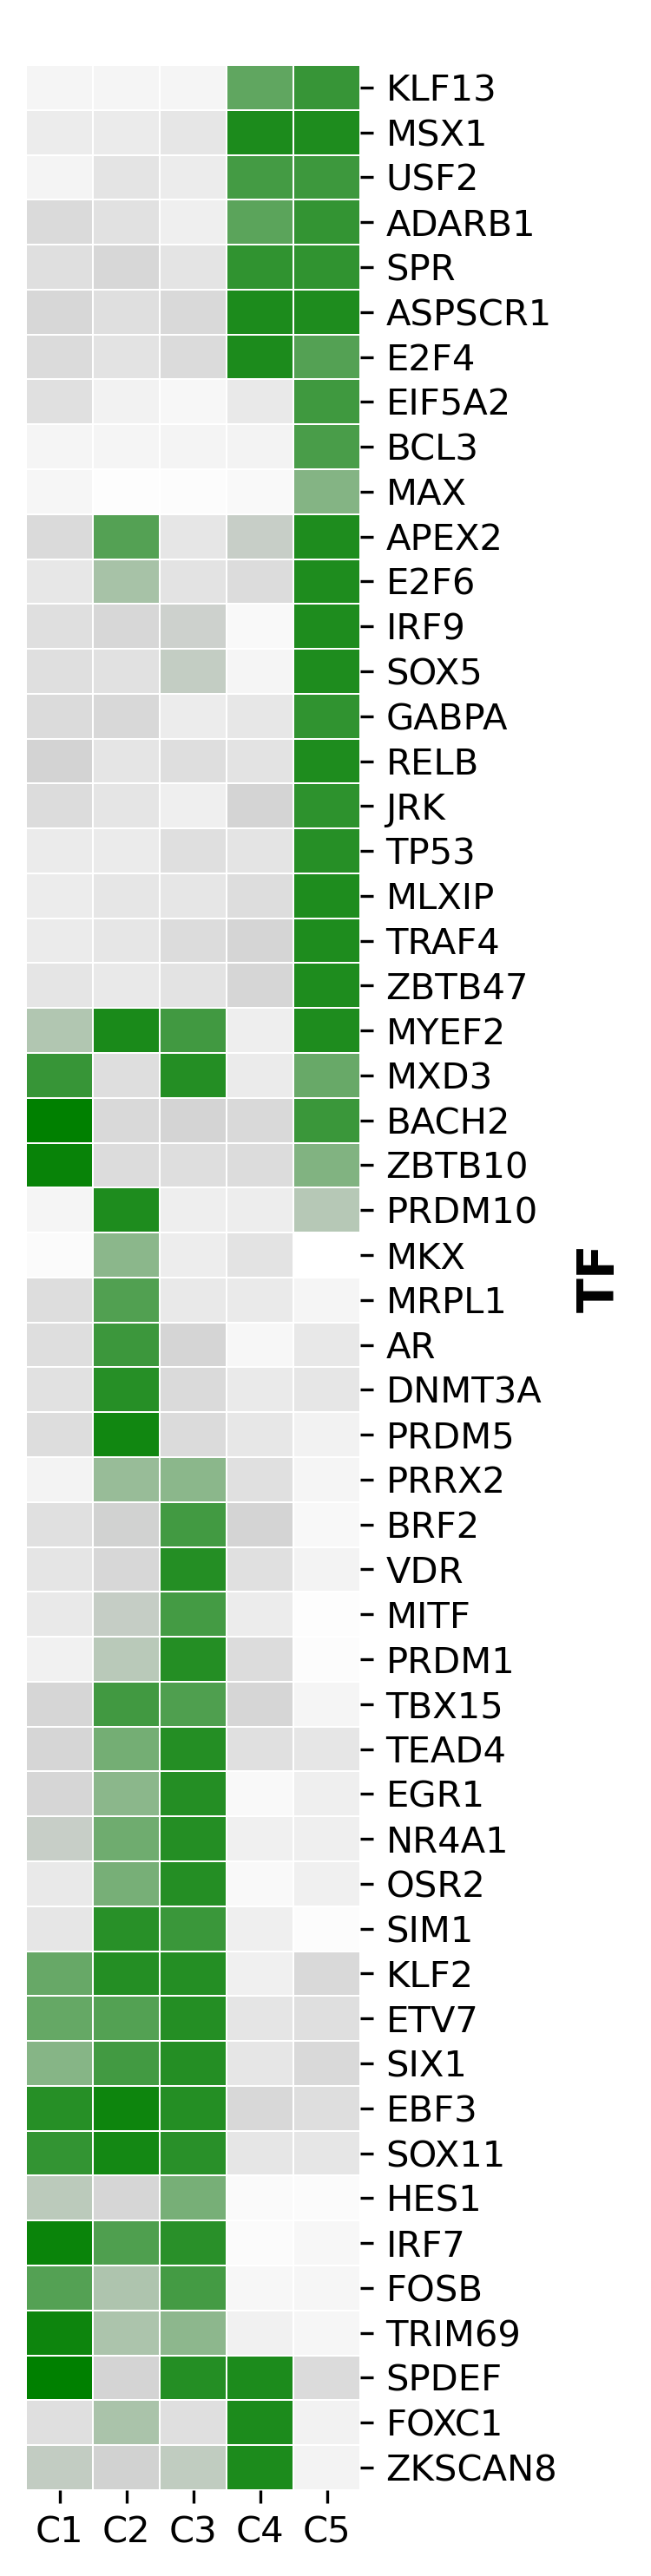

In [23]:
plot_df = final_df.copy()
plot_df = pd.pivot_table(
    plot_df,
    index='gene_name',
    columns='cluster',
    values='eigenvector_centrality',
)

# ranks to mitigate scaling issues
plot_df = plot_df.rank(
    axis=0, 
    ascending=False,
    method='min',
    pct=True,
)

plot_df = plot_df[plot_df.index.isin(tf_list)]
print(f"filter 1 {plot_df.shape=}")

# drop zinc-fingers
plot_df = plot_df[~plot_df.index.str.startswith('ZNF')]
print(f"filter 2 {plot_df.shape=}")

plot_df = plot_df[plot_df.std(axis=1) > 0.25]
print(f"filter 3 {plot_df.shape=}")


print(plot_df.round(2).to_string())

cmap = LinearSegmentedColormap.from_list('test', ['w', 'lightgrey', 'green'])

g = sns.clustermap(
    data=plot_df,                # Remove .T; already clusters=columns, TFs=index
    cmap=cmap,
    linewidths=0.4,
    linecolor='white',
    figsize=(2.75, 10),           # Make taller for TFs on y-axis
    row_cluster=True,
    cbar_pos=None,
    xticklabels=True,            # Clusters
    yticklabels=True,            # TF names
    method='average',
    metric='euclidean',
    z_score=None,
    dendrogram_ratio=(0.0, 0.0),
    colors_ratio=0.1,
)

# Hide the row dendrogram axis (if present)
if hasattr(g, 'ax_row_dendrogram'):
    g.ax_row_dendrogram.set_visible(False)

# Clean up tick labels
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=0)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

# Add labels and title
g.ax_heatmap.set_xlabel("",)
g.ax_heatmap.set_ylabel("TF", labelpad=5, fontsize=14, weight='bold')

plt.tight_layout()
plt.show()



In [35]:
query = ['SOX11']
results = []
for x in pathways_with_genes(query):
    gene_list = get_genes_from_go_path(x)
    overlap = ", ".join(plot_df.index[plot_df.index.isin(gene_list)])
    results.append({'pathway': x, 'n_overlap': len(overlap), 'overlap': overlap})

df = pd.DataFrame(results)
df = df.sort_values('n_overlap', ascending=False)

for _, row in df.iterrows():
    print(f"{row['pathway']} {row['overlap']}")

Regulation Of Transcription By RNA Polymerase II (GO:0006357) BACH2, BCL3, DNMT3A, E2F4, E2F6, EGR1, ETV7, FOSB, FOXC1, GABPA, HES1, IRF7, IRF9, KLF13, KLF2, MAX, MITF, MKX, MLXIP, MSX1, MXD3, NR4A1, OSR2, PRDM1, PRDM10, PRDM5, RELB, SIM1, SIX1, SOX11, SOX5, SPDEF, TBX15, TEAD4, TP53, USF2, ZBTB10, ZBTB47, ZKSCAN8
Positive Regulation Of Transcription By RNA Polymerase II (GO:0045944) BCL3, E2F4, EGR1, FOXC1, GABPA, HES1, IRF7, IRF9, KLF2, MAX, MITF, MLXIP, NR4A1, OSR2, PRDM10, PRDM5, RELB, SIX1, SOX11, TP53, USF2
Positive Regulation Of DNA-templated Transcription (GO:0045893) BCL3, E2F4, EGR1, FOXC1, GABPA, HES1, IRF7, IRF9, KLF2, MAX, MITF, MLXIP, NR4A1, OSR2, PRDM10, PRDM5, RELB, SIX1, SOX11, TP53, USF2
Negative Regulation Of DNA-templated Transcription (GO:0045892) BACH2, BCL3, DNMT3A, E2F6, ETV7, FOSB, FOXC1, HES1, IRF7, KLF2, MAX, MITF, OSR2, PRDM1, PRDM5, SOX11, SPDEF, TP53, ZBTB10
Negative Regulation Of Transcription By RNA Polymerase II (GO:0000122) BACH2, DNMT3A, E2F6, ETV7, F